In [5]:

from operator import imod

import numpy as np
import matplotlib.pyplot as plt

from sklearn.svm import SVR
from sklearn.decomposition import PCA
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import fetch_california_housing, load_diabetes
from sklearn.model_selection import train_test_split, GridSearchCV


"""
## Funzione di utilità

Definiamo una funzione riusabile che esegue l'intera pipeline:

1. split
2. scaling
3. modello base
4. grid search
5. confronto MSE
6. PCA
7. grafico finale con subplot
"""

In [ ]:
def run_svr_gridsearch_experiment(
    X,
    y,
    dataset_name,
    test_size=0.2,
    random_state=42,
    shuffle=True
):
    # ------------------------------------------------------------------
    # 1. Train / test split
    # ------------------------------------------------------------------
    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=test_size,
        shuffle=shuffle,
        random_state=random_state
    )

     # ------------------------------------------------------------------
    # 2. Standardizzazione
    # Fit solo sul training set; transform sul test set
    # ------------------------------------------------------------------
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # ------------------------------------------------------------------
    # 3. Modello base
    # ------------------------------------------------------------------
    svr_base = SVR(kernel="linear", C=1.0, epsilon=0.1)
    svr_base.fit(X_train_scaled, y_train)

    y_pred_base = svr_base.predict(X_test_scaled)
    mse_base = mean_squared_error(y_test, y_pred_base)


    # ------------------------------------------------------------------
    # 4. Grid Search
    # In GridSearchCV si usa neg_mean_squared_error perché lo score
    # viene massimizzato. Minimizzare l'MSE equivale a massimizzare il
    # suo opposto negativo.
    # ------------------------------------------------------------------
    param_grid = {
        "kernel": ["linear"],
        "C": [0.1, 1.0, 10.0],
        "epsilon": [0.05, 0.1, 0.2]
    }

    grid = GridSearchCV(
        estimator=SVR(),
        param_grid=param_grid,
        cv=5,
        scoring="neg_mean_squared_error",
        n_jobs=-1
    )
    grid.fit(X_train_scaled, y_train)

    best_svr = grid.best_estimator_
    y_pred_best = best_svr.predict(X_test_scaled)
    mse_best = mean_squared_error(y_test, y_pred_best)
    
    

    # ------------------------------------------------------------------
    # 5. Stampa risultati principali
    # ------------------------------------------------------------------
    print("=" * 70)
    print(f"DATASET: {dataset_name}")
    print("-" * 70)
    print("Migliori parametri trovati dalla Grid Search:")
    print(grid.best_params_)
    print(f"MSE modello base: {mse_base:.4f}")
    print(f"MSE modello ottimizzato: {mse_best:.4f}")

    if mse_best < mse_base:
        print("Interpretazione: il modello ottimizzato migliora sul test set.")
    elif mse_best > mse_base:
        print("Interpretazione: il modello ottimizzato non migliora sul test set.")
        print("Nota: è normale che la Grid Search non vinca sempre sul test finale.")
    else:
        print("Interpretazione: i due modelli hanno lo stesso MSE sul test set.")

    # ------------------------------------------------------------------
    # 6. PCA per visualizzazione
    # Uniamo train e test scalati solo per costruire una vista globale.
    # ------------------------------------------------------------------
    X_scaled_all = np.vstack([X_train_scaled, X_test_scaled])
    y_all = np.hstack([y_train, y_test])

    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X_scaled_all)

    # Usiamo PC1 per creare una visualizzazione 1D leggibile.
    X_pca_1 = X_pca[:, 0].reshape(-1, 1)

    # ------------------------------------------------------------------
    # 7. Fit 1D per visualizzazione
    # Questo serve solo a tracciare le rette in modo chiaro.
    # Non sostituisce il modello originale multivariato.
    # ------------------------------------------------------------------
    svr_base_1d = SVR(kernel="linear", C=1.0, epsilon=0.1)
    svr_base_1d.fit(X_pca_1, y_all)
    y_pred_base_1d = svr_base_1d.predict(X_pca_1)

    best_svr_1d = SVR(**grid.best_params_)
    best_svr_1d.fit(X_pca_1, y_all)
    y_pred_best_1d = best_svr_1d.predict(X_pca_1)

    # Ordiniamo i punti per evitare linee spezzate nel plot
    sort_idx = np.argsort(X_pca_1[:, 0])
    X_plot = X_pca_1[sort_idx]
    y_plot_base = y_pred_base_1d[sort_idx]
    y_plot_best = y_pred_best_1d[sort_idx]


    # ------------------------------------------------------------------
    # 8. Grafico finale con subplot
    # ------------------------------------------------------------------
    fig, axes = plt.subplots(1, 2, figsize=(12, 6), sharey=True)

    # Subplot 1: modello base
    axes[0].scatter(
        X_pca_1,
        y_all,
        alpha=0.5,
        s=20,
        label="Dati reali"
    )
    axes[0].plot(
        X_plot,
        y_plot_base,
        linewidth=2,
        label="SVR base"
    )
    axes[0].set_title(f"{dataset_name} - SVR base")
    axes[0].set_xlabel("PC1")
    axes[0].set_ylabel("Target")
    axes[0].grid(True, linestyle="--", alpha=0.6)
    axes[0].legend()

    # Subplot 2: modello ottimizzato
    axes[1].scatter(
        X_pca_1,
        y_all,
        alpha=0.5,
        s=20,
        label="Dati reali"
    )
    axes[1].plot(
        X_plot,
        y_plot_best,
        linewidth=2,
        label="SVR ottimizzato"
    )
    axes[1].set_title(f"{dataset_name} - SVR best model")
    axes[1].set_xlabel("PC1")
    axes[1].grid(True, linestyle="--", alpha=0.6)
    axes[1].legend()

    plt.suptitle(f"Confronto SVR su PCA - {dataset_name}", fontsize=14)
    plt.tight_layout()
    plt.show()



    

    # ------------------------------------------------------------------
    # 9. Return risultati
    # ------------------------------------------------------------------
    results = {
        "dataset_name": dataset_name,
        "scaler": scaler,
        "svr_base": svr_base,
        "best_svr": best_svr,
        "grid": grid,
        "mse_base": mse_base,
        "mse_best": mse_best,
        "pca": pca,
        "explained_variance_ratio": pca.explained_variance_ratio_,
        "X_train_scaled": X_train_scaled,
        "X_test_scaled": X_test_scaled,
        "y_train": y_train,
        "y_test": y_test,
    }

    return results




In [7]:

"""
## Esercizio 1 - California Housing

Questo blocco riproduce il workflow mostrato nel primo notebook fornito.
"""

'\n## Esercizio 1 - California Housing\n\nQuesto blocco riproduce il workflow mostrato nel primo notebook fornito.\n'

DATASET: California Housing
----------------------------------------------------------------------
Migliori parametri trovati dalla Grid Search:
{'C': 0.1, 'epsilon': 0.2, 'kernel': 'linear'}
MSE modello base: 0.5793
MSE modello ottimizzato: 0.5781
Interpretazione: il modello ottimizzato migliora sul test set.


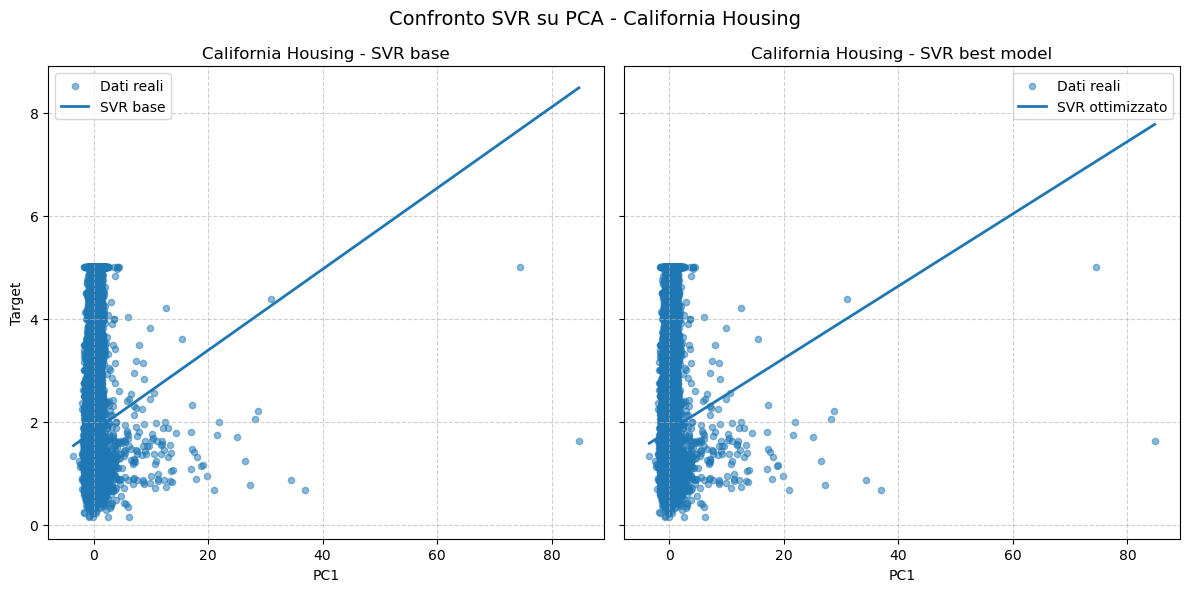

In [8]:
# Caricamento dataset California Housing
california_data = fetch_california_housing()
X_california, y_california = california_data.data, california_data.target

# Esecuzione pipeline completa
results_california = run_svr_gridsearch_experiment(
    X=X_california,
    y=y_california,
    dataset_name="California Housing"
)